<a href="https://colab.research.google.com/github/phailin-kopong/milklab-sip-and-chill/blob/main/RAG_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers faiss-cpu google-generativeai matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 55.6 MB/s eta 0:00:00


In [3]:
# สร้างไฟล์ menu_kb.md สำหรับเก็บข้อมูลร้าน MilkLab
kb_content = """
ร้าน MilkLab เปิดให้บริการทุกวันจันทร์ - เสาร์ เวลา 08:00 - 18:00 น. ปิดให้บริการทุกวันอาทิตย์ ร้านตั้งอยู่ที่หน้าปากซอยมหาวิทยาลัย

รายการเมนูเครื่องดื่มของร้าน MilkLab:
1. นมสดบราวน์ชูการ์ (Signature) - ราคา 65 บาท (หอมหวานจากน้ำตาลทรายแดงแท้)
2. นมสดสตรอว์เบอร์รี - ราคา 60 บาท (ใช้สตรอว์เบอร์รีสดเคี่ยวเอง)
3. ชาไทยนมสด - ราคา 50 บาท
4. มัทฉะลาเต้ - ราคา 70 บาท (ผงมัทฉะเกรดพรีเมียมจากอุจิ)

ทางเลือกสำหรับคนแพ้นมวัวหรือต้องการเปลี่ยนประเภทนม:
- นมข้าวโอ๊ต (Oat Milk) บวกเพิ่ม 15 บาท
- นมอัลมอนด์ (Almond Milk) บวกเพิ่ม 15 บาท

ข้อมูล Allergen (สารก่อภูมิแพ้):
- เมนูชาไทยและมัทฉะมีส่วนผสมของถั่วในบางกระบวนการ
- เครื่องดื่มปกติใช้นมวัวพาสเจอร์ไรส์ 100%
"""

with open("menu_kb.md", "w", encoding="utf-8") as f:
    f.write(kb_content.strip())

print("สร้างไฟล์ menu_kb.md สำเร็จเรียบร้อย!")

สร้างไฟล์ menu_kb.md สำเร็จเรียบร้อย!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import faiss

# 1. อ่านไฟล์ KB และ Split ย่อหน้า (Chunk)
with open("menu_kb.md", "r", encoding="utf-8") as f:
    text = f.read()

chunks = [c.strip() for c in text.split("\n\n") if len(c.strip()) > 10]

# แสดง Index ของแต่ละ Chunk ให้เห็นชัดเจน (ใช้ดูเวลาทำ Ground Truth)
print("=== รายการ Chunks ในระบบ ===")
for i, chunk in enumerate(chunks):
    print(f"📌 [Chunk Index {i}]:")
    print(chunk)
    print("-" * 40)

# 2. ทำ Embedding และสร้าง FAISS Index
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = embedder.encode(chunks)

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print("\nสร้าง FAISS Index สำเร็จแล้ว!")

=== รายการ Chunks ในระบบ ===
📌 [Chunk Index 0]:
ร้าน MilkLab เปิดให้บริการทุกวันจันทร์ - เสาร์ เวลา 08:00 - 18:00 น. ปิดให้บริการทุกวันอาทิตย์ ร้านตั้งอยู่ที่หน้าปากซอยมหาวิทยาลัย
----------------------------------------
📌 [Chunk Index 1]:
รายการเมนูเครื่องดื่มของร้าน MilkLab:
1. นมสดบราวน์ชูการ์ (Signature) - ราคา 65 บาท (หอมหวานจากน้ำตาลทรายแดงแท้)
2. นมสดสตรอว์เบอร์รี - ราคา 60 บาท (ใช้สตรอว์เบอร์รีสดเคี่ยวเอง)
3. ชาไทยนมสด - ราคา 50 บาท
4. มัทฉะลาเต้ - ราคา 70 บาท (ผงมัทฉะเกรดพรีเมียมจากอุจิ)
----------------------------------------
📌 [Chunk Index 2]:
ทางเลือกสำหรับคนแพ้นมวัวหรือต้องการเปลี่ยนประเภทนม:
- นมข้าวโอ๊ต (Oat Milk) บวกเพิ่ม 15 บาท
- นมอัลมอนด์ (Almond Milk) บวกเพิ่ม 15 บาท
----------------------------------------
📌 [Chunk Index 3]:
ข้อมูล Allergen (สารก่อภูมิแพ้):
- เมนูชาไทยและมัทฉะมีส่วนผสมของถั่วในบางกระบวนการ
- เครื่องดื่มปกติใช้นมวัวพาสเจอร์ไรส์ 100%
----------------------------------------


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


สร้าง FAISS Index สำเร็จแล้ว!


=== ผลการประเมิน Mini Eval ===
Average Precision@3: 0.3333
Average Recall@3: 1.0000



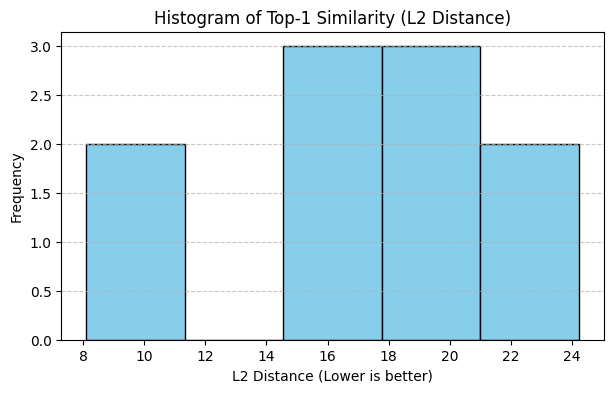

In [5]:
# 1. กำหนด Ground Truth 10 คำถาม และ Index ของ Chunk ที่ถูกต้อง
eval_dataset = [
    {"question": "ร้านเปิดปิดกี่โมง?", "relevant_chunk_indices": [0]},
    {"question": "ร้านตั้งอยู่ที่ไหน?", "relevant_chunk_indices": [0]},
    {"question": "เมนู Signature ของร้านคืออะไร ราคาเท่าไหร่?", "relevant_chunk_indices": [1]},
    {"question": "มัทฉะลาเต้ราคาเท่าไหร่?", "relevant_chunk_indices": [1]},
    {"question": "ชานมไทยราคาเท่าไหร่?", "relevant_chunk_indices": [1]},
    {"question": "ถ้าแพ้นมวัว เปลี่ยนเป็นนมอะไรได้บ้าง?", "relevant_chunk_indices": [2]},
    {"question": "ค่านมข้าวโอ๊ตบวกเพิ่มกี่บาท?", "relevant_chunk_indices": [2]},
    {"question": "คนแพ้ถั่วทานชาไทยได้ไหม?", "relevant_chunk_indices": [3]},
    {"question": "เครื่องดื่มปกติใช้นมอะไร?", "relevant_chunk_indices": [3]},
    {"question": "ร้านเปิดวันอาทิตย์ไหม?", "relevant_chunk_indices": [0]},
]

k = 3
precisions = []
recalls = []
top1_distances = []

# 2. คำนวณ Precision@3 และ Recall@3
for item in eval_dataset:
    query = item["question"]
    ground_truth = set(item["relevant_chunk_indices"])

    query_vec = embedder.encode([query])
    distances, indices = index.search(np.array(query_vec), k)

    retrieved = set(indices[0])
    top1_distances.append(distances[0][0])

    intersection = retrieved.intersection(ground_truth)

    p_at_k = len(intersection) / k
    r_at_k = len(intersection) / len(ground_truth) if len(ground_truth) > 0 else 0

    precisions.append(p_at_k)
    recalls.append(r_at_k)

print(f"=== ผลการประเมิน Mini Eval ===")
print(f"Average Precision@{k}: {np.mean(precisions):.4f}")
print(f"Average Recall@{k}: {np.mean(recalls):.4f}\n")

# 3. วาดกราฟ Histogram ของ Top-1 Distance
plt.figure(figsize=(7, 4))
plt.hist(top1_distances, bins=5, color='skyblue', edgecolor='black')
plt.title("Histogram of Top-1 Similarity (L2 Distance)")
plt.xlabel("L2 Distance (Lower is better)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
%%writefile app.py
import streamlit as st
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import google.generativeai as genai
import os

# ตั้งค่า API Key
if "GEMINI_API_KEY" in st.secrets:
    genai.configure(api_key=st.secrets["GEMINI_API_KEY"])
elif "GEMINI_API_KEY" in os.environ:
    genai.configure(api_key=os.environ["GEMINI_API_KEY"])

llm = genai.GenerativeModel('gemini-1.5-flash')

@st.cache_resource
def load_rag():
    embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    with open("menu_kb.md", "r", encoding="utf-8") as f:
        text = f.read()
    chunks = [c.strip() for c in text.split("\n\n") if len(c.strip()) > 10]

    embeddings = embedder.encode(chunks)
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(np.array(embeddings))
    return embedder, index, chunks

embedder, index, chunks = load_rag()

st.title("🥛 MilkLab Chatbot (RAG)")

if "messages" not in st.session_state:
    st.session_state.messages = []

for msg in st.session_state.messages:
    st.chat_message(msg["role"]).write(msg["content"])

if prompt := st.chat_input("ถามข้อมูลร้าน MilkLab ได้เลยครับ..."):
    st.session_state.messages.append({"role": "user", "content": prompt})
    st.chat_message("user").write(prompt)

    # Retrieve Context
    query_vec = embedder.encode([prompt])
    distances, indices = index.search(np.array(query_vec), 3)
    retrieved_context = "\n---\n".join([chunks[i] for i in indices[0]])

    # Generate Prompt
    full_prompt = f"ตอบคำถามลูกค้าอ้างอิงจากข้อมูลนี้เท่านั้น:\n{retrieved_context}\n\nคำถาม: {prompt}"

    try:
        response = llm.generate_content(full_prompt)
        reply = response.text
    except Exception as e:
        reply = f"เกิดข้อผิดพลาด: {e}"

    st.session_state.messages.append({"role": "assistant", "content": reply})
    st.chat_message("assistant").write(reply)

Overwriting app.py
